In [69]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataFrame = pd.read_csv("application_record.csv")

In [3]:
dataFrame

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438552,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,NaN,1.0
438553,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0
438554,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0
438555,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,NaN,2.0


In [13]:
dataFrame.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
5,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
6,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [5]:
dataFrame.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,4.385570e+05,438557.000000,4.385570e+05,438557.000000,438557.000000,438557.0,438557.000000,438557.000000,438557.000000,438557.000000
mean,6.022176e+06,0.427390,1.875243e+05,-15997.904649,60563.675328,1.0,0.206133,0.287771,0.108207,2.194465
std,5.716370e+05,0.724882,1.100869e+05,4185.030007,138767.799647,0.0,0.404527,0.452724,0.310642,0.897207
min,5.008804e+06,0.000000,2.610000e+04,-25201.000000,-17531.000000,1.0,0.000000,0.000000,0.000000,1.000000
25%,5.609375e+06,0.000000,1.215000e+05,-19483.000000,-3103.000000,1.0,0.000000,0.000000,0.000000,2.000000
50%,6.047745e+06,0.000000,1.607805e+05,-15630.000000,-1467.000000,1.0,0.000000,0.000000,0.000000,2.000000
75%,6.456971e+06,1.000000,2.250000e+05,-12514.000000,-371.000000,1.0,0.000000,1.000000,0.000000,3.000000
max,7.999952e+06,19.000000,6.750000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000


In [6]:
dataFrame.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [10]:
dataFrame.dropna(subset=["OCCUPATION_TYPE"], inplace=True)

In [12]:
print("Temizlik Sonrası Eksik Veri Sayıları:")
dataFrame.isnull().sum()

Temizlik Sonrası Eksik Veri Sayıları:


ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
dtype: int64

In [16]:
dataFrame["AGE_YEARS"] = (abs(dataFrame["DAYS_BIRTH"]) / 365).astype(int)
dataFrame["DAYS_EMPLOYED"] = dataFrame["DAYS_EMPLOYED"].replace(365243, 0)
dataFrame["YEARS_EMPLOYED"] = (abs(dataFrame["DAYS_EMPLOYED"]) / 365).round(1)

In [17]:
dataFrame = dataFrame.drop(["DAYS_BIRTH","DAYS_EMPLOYED"], axis=1)

In [18]:
print(dataFrame[["AGE_YEARS","YEARS_EMPLOYED"]].describe())

          AGE_YEARS  YEARS_EMPLOYED
count  304354.00000   304354.000000
mean       40.06248        7.183482
std         9.55508        6.576310
min        20.00000        0.000000
25%        32.00000        2.500000
50%        39.00000        5.300000
75%        47.00000        9.600000
max        67.00000       48.000000


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE_YEARS,YEARS_EMPLOYED
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,58,3.1
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,8.4
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,8.4
5,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,8.4
6,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,8.4


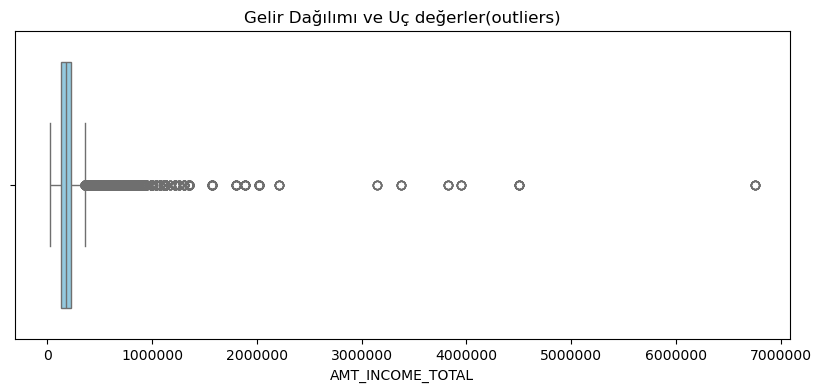

In [23]:
# gelir dağılımındaki uç değerleri görelim
plt.figure(figsize=(10,4))
sns.boxplot(x = dataFrame["AMT_INCOME_TOTAL"], color="skyblue")
plt.title("Gelir Dağılımı ve Uç değerler(outliers)")
plt.ticklabel_format(style="plain", axis="x")
plt.show()

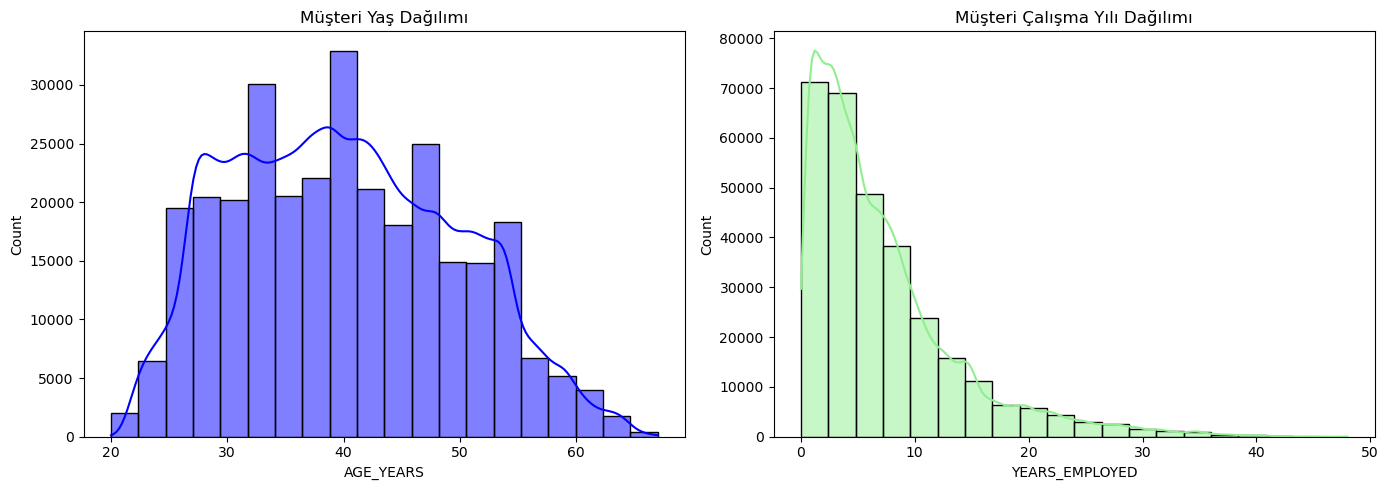

In [25]:
#Oluşturduğumuz Yaş ve Çalışma Yılı Dağılımına Bakalım
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(dataFrame["AGE_YEARS"], bins=20, kde=True, ax=axes[0], color="blue")
axes[0].set_title("Müşteri Yaş Dağılımı")
sns.histplot(dataFrame["YEARS_EMPLOYED"], bins=20, kde=True, ax=axes[1],color="lightgreen")
axes[1].set_title("Müşteri Çalışma Yılı Dağılımı")
plt.tight_layout()
plt.show()

C:\Users\bilte\AppData\Local\Temp\ipykernel_7692\3111035772.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataFrame, x="NAME_EDUCATION_TYPE", palette="Set2")


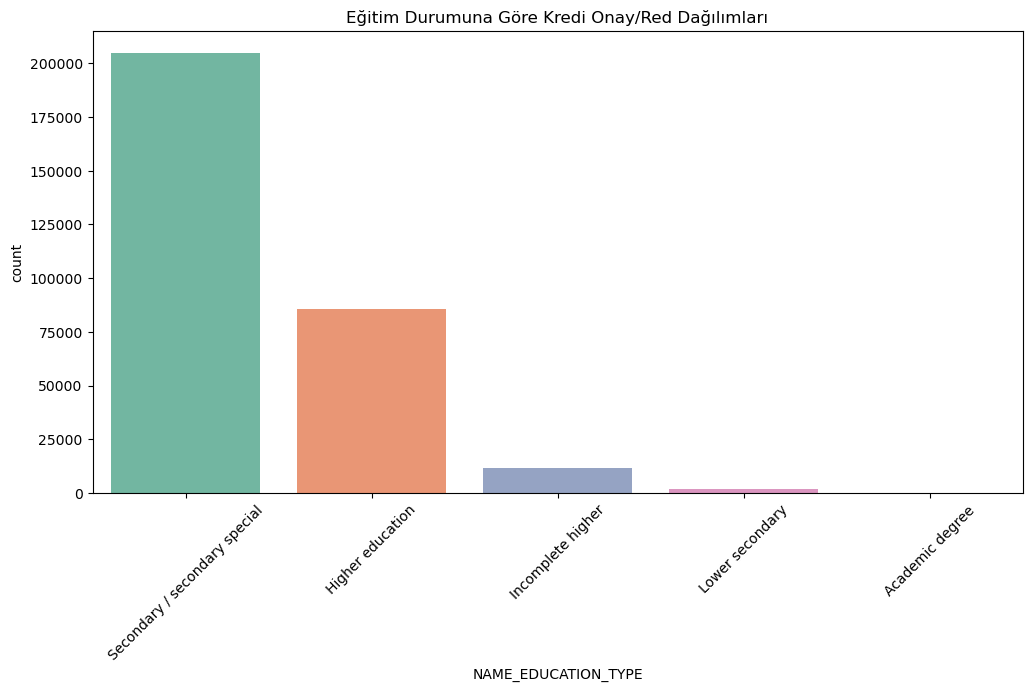

In [27]:
# Eğitim Durumuna Göre Kredi Onay/Red Dağılımları
plt.figure(figsize=(12,6))
sns.countplot(data=dataFrame, x="NAME_EDUCATION_TYPE", palette="Set2")
plt.xticks(rotation=45)
plt.title("Eğitim Durumuna Göre Kredi Onay/Red Dağılımları")
plt.show()

In [28]:
print(dataFrame.columns)

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_MOBIL',
       'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE',
       'CNT_FAM_MEMBERS', 'AGE_YEARS', 'YEARS_EMPLOYED'],
      dtype='object')


In [29]:
credit = pd.read_csv("credit_record.csv")

In [30]:
credit

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048570,5150487,-25,C
1048571,5150487,-26,C
1048572,5150487,-27,C
1048573,5150487,-28,C


In [41]:
# 2. Risk Sınıflandırması
# '2', '3', '4', '5' değerleri 60 günden fazla gecikmeyi ifade eder. Bunları 1 (Riskli) yapıyoruz.
credit['TARGET'] = np.where(credit['STATUS'].isin(['2', '3', '4', '5']), 1, 0)

In [42]:
# 3. Her müşteri (ID) için tek bir sonuç çıkarıyoruz
# Eğer müşteri bir kere bile '1' durumuna düştüyse, o müşteriyi riskli sayıyoruz.
target_df = credit.groupby('ID')['TARGET'].max().reset_index()

In [46]:
# 1. Çiftlenen Target sütununun birini silip, diğerinin adını düzeltiyoruz
dataFrame = dataFrame.drop('TARGET_y', axis=1)
dataFrame = dataFrame.rename(columns={'TARGET_x': 'TARGET'})

# 2. Aradan sızan OCCUPATION_TYPE sütununu kalıcı olarak tekrar uçuruyoruz
dataFrame = dataFrame.drop('OCCUPATION_TYPE', axis=1)

# Tablonun son haline bakalım
print(dataFrame.columns)

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_MOBIL',
       'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS',
       'AGE_YEARS', 'YEARS_EMPLOYED', 'TARGET'],
      dtype='object')


In [54]:
le = LabelEncoder()

In [55]:
binary_cols = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']
for col in binary_cols:
    dataFrame[col] = le.fit_transform(dataFrame[col])

In [57]:
#  ENCODING: ÇOK SEÇENEKLİ KATEGORİLERİ DÖNÜŞTÜRME
categorical_cols = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']
dataFrame = pd.get_dummies(dataFrame, columns=categorical_cols, drop_first=True)

KeyError: "None of [Index(['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',\n       'NAME_HOUSING_TYPE'],\n      dtype='object')] are in the [columns]"

In [58]:
print(dataFrame.columns)

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE_YEARS', 'YEARS_EMPLOYED',
       'TARGET', 'NAME_INCOME_TYPE_Pensioner',
       'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Student',
       'NAME_INCOME_TYPE_Working', 'NAME_EDUCATION_TYPE_Higher education',
       'NAME_EDUCATION_TYPE_Incomplete higher',
       'NAME_EDUCATION_TYPE_Lower secondary',
       'NAME_EDUCATION_TYPE_Secondary / secondary special',
       'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated',
       'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Widow',
       'NAME_HOUSING_TYPE_House / apartment',
       'NAME_HOUSING_TYPE_Municipal apartment',
       'NAME_HOUSING_TYPE_Office apartment',
       'NAME_HOUSING_TYPE_Rented apartment', 'NAME_HOUSING_TYPE_With parents'],
      dtype='object')


In [61]:
# (2) Makine Öğrenmesi Modelinin Seçilmesi - KNN Sınıflandırıcı
# (3) Modelin Train Edilmesi
X = dataFrame.drop("TARGET", axis=1) # features
y = dataFrame["TARGET"] # target

In [62]:
print("X'in boyutu:", X.shape)
print("y'nin boyutu:", y.shape)

X'in boyutu: (25134, 29)
y'nin boyutu: (25134,)


In [63]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [65]:
# olceklendirme(elimizdeki veri setinin olceklendiriyor)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("VERİ başarıyla parçalandı ve ölçeklendi")

VERİ başarıyla parçalandı ve ölçeklendi


In [67]:
# knn modeli olustur ve train et
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [68]:
y_pred = knn.predict(X_test)

In [70]:
accuracy = accuracy_score(y_test, y_pred)
print("Doğruluk: ", accuracy)

Doğruluk:  0.980771780930911


In [71]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("confusion_matrix:")
print(conf_matrix)

confusion_matrix:
[[7380   30]
 [ 115   16]]


In [74]:
# hiperparametre ayalarması : yapmam daki ana neden doğruluğu arttırmak
"""
    KNN: Hyperparameter = K
    K: 1,2,3,...,N
    Accuracy: %A, %B, %C
"""
accuracy_value = []
k_values = []
for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    accuracy_value.append(accuracy)
    k_values.append(k)

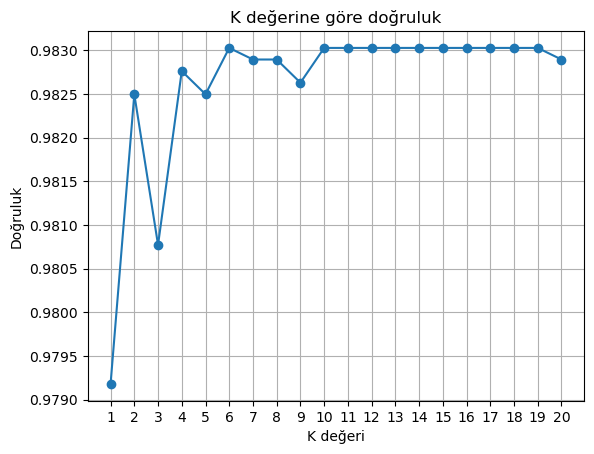

In [75]:
plt.figure()
plt.plot(k_values, accuracy_value, marker = "o", linestyle = "-")
plt.title("K değerine göre doğruluk")
plt.xlabel("K değeri")
plt.ylabel("Doğruluk")
plt.xticks(k_values)
plt.grid(True)